<a href="https://colab.research.google.com/github/MDADILIFTEKHAR/Major-Project-Seasonal-Agriculture-Performance-Analysis/blob/main/Major_Project_Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import the libraries required for the analysis

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

print("File uploaded successfully.")

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv
File uploaded successfully.


In [3]:
import os

file_name = list(uploaded.keys())[0]

if file_name.endswith(".csv"):
    df = pd.read_csv(file_name)

elif file_name.endswith(".xlsx") or file_name.endswith(".xls"):
    df = pd.read_excel(file_name)

else:
    raise ValueError("Please upload a CSV or Excel file.")

print("Dataset loaded successfully.")
print("File:", file_name)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
File: seasonal_agriculture_performance_dataset (1).csv
Rows: 4000
Columns: 28


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
for column in df.columns:
    print("-", column)

print("\nFirst 5 Records:")
display(df.head())

Dataset Shape:
(4000, 28)

Column Names:
- Farm_ID
- State
- District
- Crop
- Season
- Farm_Area_Hectares
- Rainfall_mm
- Avg_Temperature_C
- Humidity_pct
- Sunlight_Hours_Day
- Soil_pH
- Soil_Moisture_pct
- Nitrogen_kg_ha
- Phosphorus_kg_ha
- Potassium_kg_ha
- Irrigation_Method
- Fertilizer_kg_ha
- Pesticide_Litre_ha
- Seed_Quality_Score
- Yield_Tonnes_Ha
- Production_Tonnes
- Market_Price_INR_Tonne
- Total_Cost_INR
- Revenue_INR
- Profit_INR
- Water_Used_m3
- Water_Efficiency_t_per_1000m3
- Disease_Pest_Risk_pct

First 5 Records:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha              

In [6]:
print("Statistical Summary")
display(df.describe(include="all").T)

Statistical Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [7]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing Percentage":
        (missing_values.values / len(df) * 100).round(2)
})

missing_table = missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_table)

,Column,Missing Values,Missing Percentage
6,Rainfall_mm,48,1.2
11,Soil_Moisture_pct,40,1.0
19,Yield_Tonnes_Ha,32,0.8
0,Farm_ID,0,0.0
3,Crop,0,0.0
2,District,0,0.0
5,Farm_Area_Hectares,0,0.0
4,Season,0,0.0
7,Avg_Temperature_C,0,0.0
8,Humidity_pct,0,0.0


In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


In [9]:
# Remove unnecessary spaces from column names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['farm_id', 'state', 'district', 'crop', 'season', 'farm_area_hectares', 'rainfall_mm', 'avg_temperature_c', 'humidity_pct', 'sunlight_hours_day', 'soil_ph', 'soil_moisture_pct', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha', 'irrigation_method', 'fertilizer_kg_ha', 'pesticide_litre_ha', 'seed_quality_score', 'yield_tonnes_ha', 'production_tonnes', 'market_price_inr_tonne', 'total_cost_inr', 'revenue_inr', 'profit_inr', 'water_used_m3', 'water_efficiency_t_per_1000m3', 'disease_pest_risk_pct']


In [10]:
# Separate numerical and categorical columns

numeric_columns = df.select_dtypes(
    include=np.number
).columns

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns

# Fill numerical missing values using median
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill categorical missing values using mode
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values handled successfully.")

Missing values handled successfully.


In [11]:
print("Remaining missing values:")
print(df.isnull().sum().sum())

print("\nFinal dataset shape:")
print(df.shape)

Remaining missing values:
0

Final dataset shape:
(4000, 28)


In [12]:
possible_season_columns = [
    col for col in df.columns
    if any(word in col.lower()
           for word in ["season", "crop_season", "period"])
]

print("Possible season columns:")
print(possible_season_columns)

Possible season columns:
['season']


In [13]:
season_col = "season"

In [14]:
season_counts = df[season_col].value_counts()

print("Number of records in each season:")
display(season_counts)

Number of records in each season:


,count
season,
Kharif,1779
Rabi,1627
Zaid,594


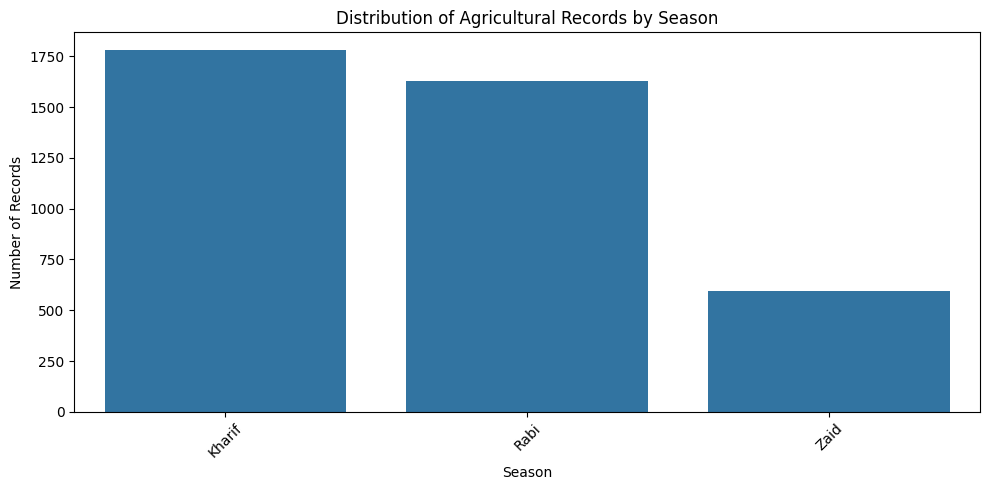

In [15]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x=season_col,
    order=df[season_col].value_counts().index
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
possible_performance_columns = [
    col for col in df.columns
    if any(word in col.lower()
           for word in [
               "yield",
               "production",
               "output",
               "productivity",
               "performance"
           ])
]

print("Possible agricultural performance columns:")
print(possible_performance_columns)

Possible agricultural performance columns:
['yield_tonnes_ha', 'production_tonnes']


In [21]:
performance_col = "yield_tonnes_ha"

In [36]:
season_performance = (
    df.groupby(season_col)[performance_col]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .round(2)
)

display(season_performance)

,count,mean,median,min,max,std
season,,,,,,
Kharif,1779,5.63,1.94,0.3,101.44,14.39
Rabi,1627,5.04,1.67,0.3,93.13,12.75
Zaid,594,4.64,1.46,0.3,64.76,11.27


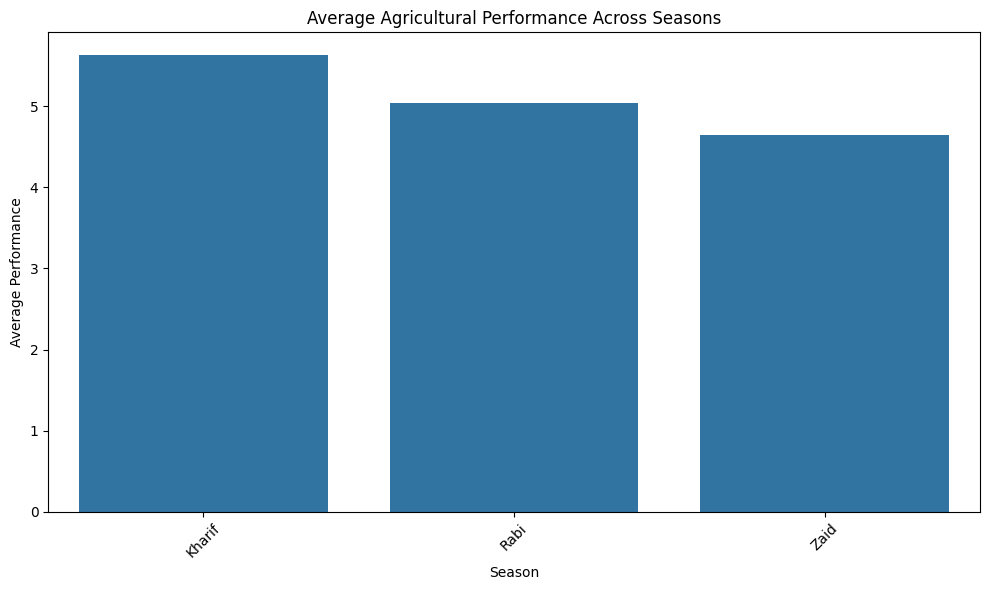

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x=season_col,
    y=performance_col,
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Agricultural Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Performance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

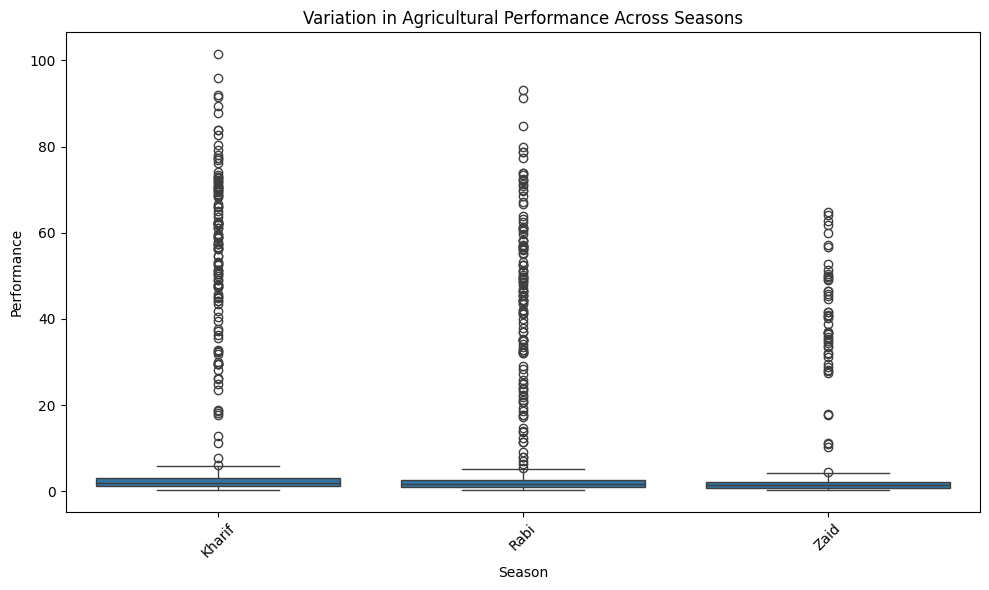

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x=season_col,
    y=performance_col
)

plt.title("Variation in Agricultural Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Performance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [25]:
environment_columns = [
    col for col in df.columns
    if any(word in col.lower()
           for word in [
               "temperature",
               "rainfall",
               "humidity",
               "precipitation",
               "weather",
               "soil",
               "moisture"
           ])
]

print("Possible environmental variables:")
print(environment_columns)

Possible environmental variables:
['rainfall_mm', 'avg_temperature_c', 'humidity_pct', 'soil_ph', 'soil_moisture_pct']


In [26]:
for column in environment_columns:

    if pd.api.types.is_numeric_dtype(df[column]):

        seasonal_environment = (
            df.groupby(season_col)[column]
            .mean()
            .sort_values(ascending=False)
        )

        print("\n", column)
        display(seasonal_environment)


 rainfall_mm


,rainfall_mm
season,
Kharif,849.199663
Rabi,437.615366
Zaid,304.654714



 avg_temperature_c


,avg_temperature_c
season,
Zaid,31.042088
Kharif,28.454019
Rabi,23.489183



 humidity_pct


,humidity_pct
season,
Kharif,71.812591
Rabi,57.893178
Zaid,52.012121



 soil_ph


,soil_ph
season,
Kharif,6.727993
Zaid,6.694865
Rabi,6.673749



 soil_moisture_pct


,soil_moisture_pct
season,
Kharif,31.149859
Rabi,24.069392
Zaid,19.279630


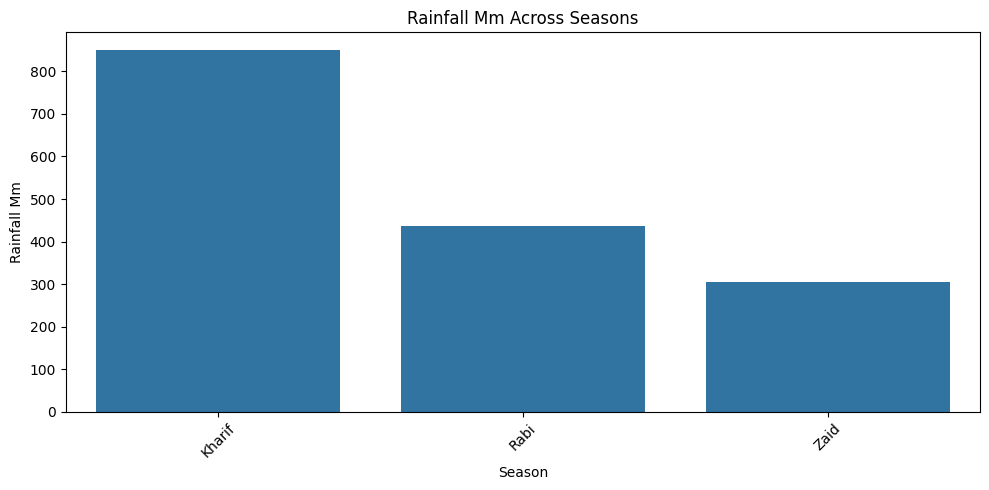

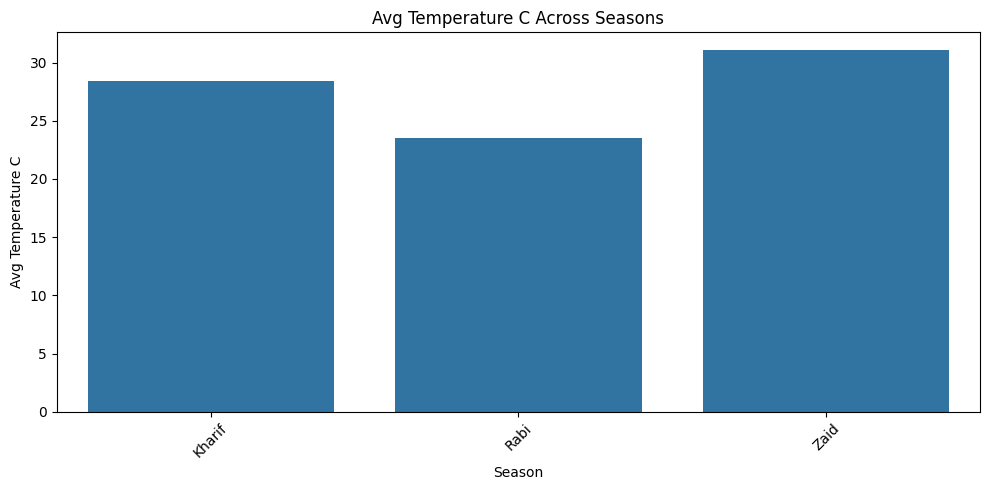

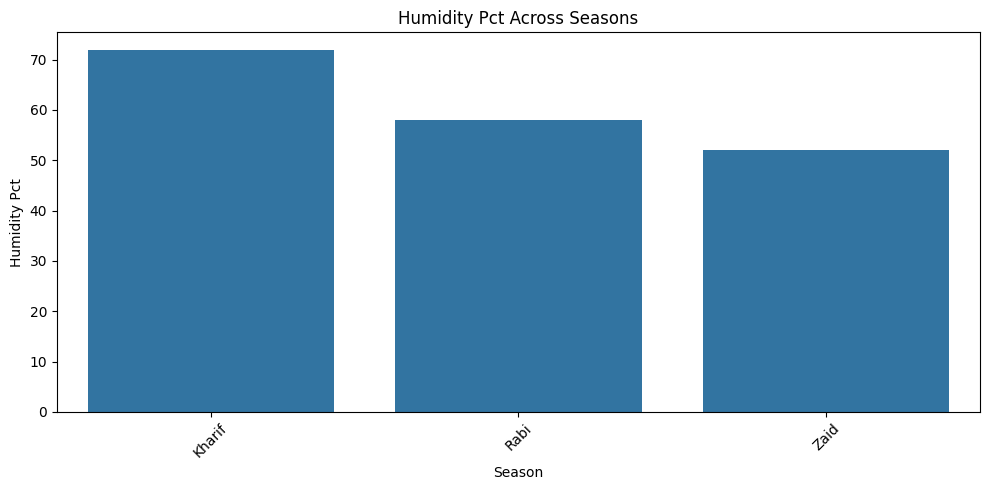

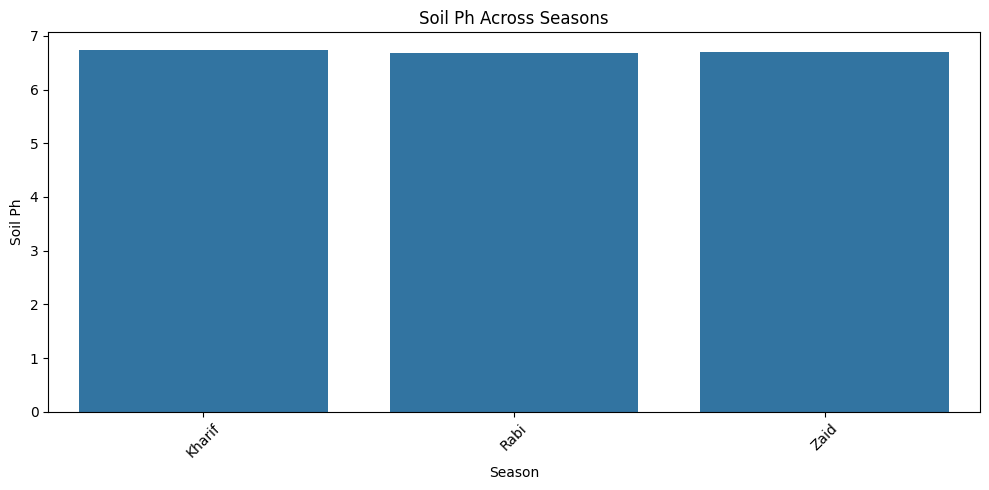

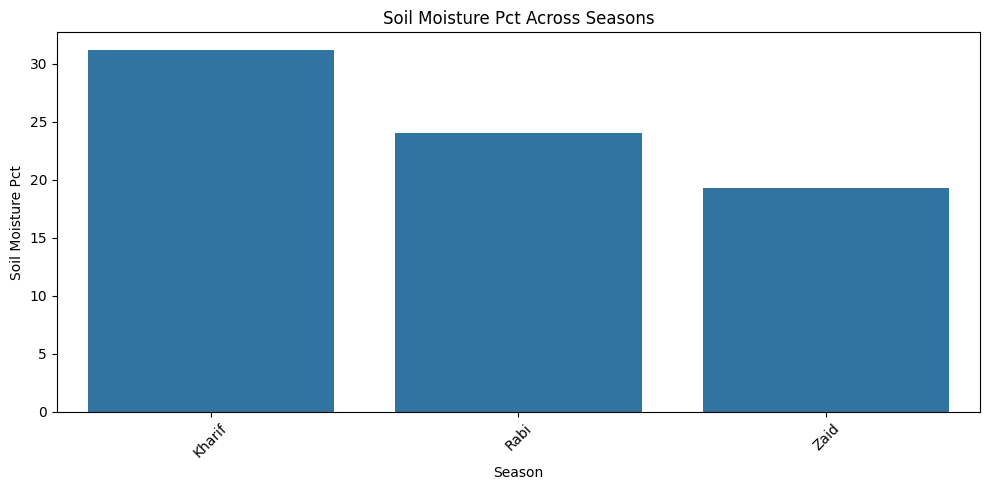

In [27]:
for column in environment_columns:

    if pd.api.types.is_numeric_dtype(df[column]):

        plt.figure(figsize=(10, 5))

        sns.barplot(
            data=df,
            x=season_col,
            y=column,
            estimator=np.mean,
            errorbar=None
        )

        plt.title(f"{column.replace('_', ' ').title()} Across Seasons")
        plt.xlabel("Season")
        plt.ylabel(column.replace("_", " ").title())
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

In [28]:
resource_columns = [
    col for col in df.columns
    if any(word in col.lower()
           for word in [
               "water",
               "irrigation",
               "fertilizer",
               "pesticide",
               "labor",
               "labour",
               "seed",
               "resource"
           ])
]

print("Possible resource columns:")
print(resource_columns)

Possible resource columns:
['irrigation_method', 'fertilizer_kg_ha', 'pesticide_litre_ha', 'seed_quality_score', 'water_used_m3', 'water_efficiency_t_per_1000m3']


In [29]:
for column in resource_columns:

    if pd.api.types.is_numeric_dtype(df[column]):

        result = (
            df.groupby(season_col)[column]
            .mean()
            .sort_values(ascending=False)
        )

        print(f"\nAverage {column} by season:")
        display(result)


Average fertilizer_kg_ha by season:


,fertilizer_kg_ha
season,
Kharif,187.077965
Rabi,185.407068
Zaid,184.638047



Average pesticide_litre_ha by season:


,pesticide_litre_ha
season,
Zaid,5.171212
Kharif,5.079747
Rabi,5.024690



Average seed_quality_score by season:


,seed_quality_score
season,
Rabi,0.832170
Zaid,0.823165
Kharif,0.821613



Average water_used_m3 by season:


,water_used_m3
season,
Zaid,6419.893939
Kharif,6102.201237
Rabi,5846.987093



Average water_efficiency_t_per_1000m3 by season:


,water_efficiency_t_per_1000m3
season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


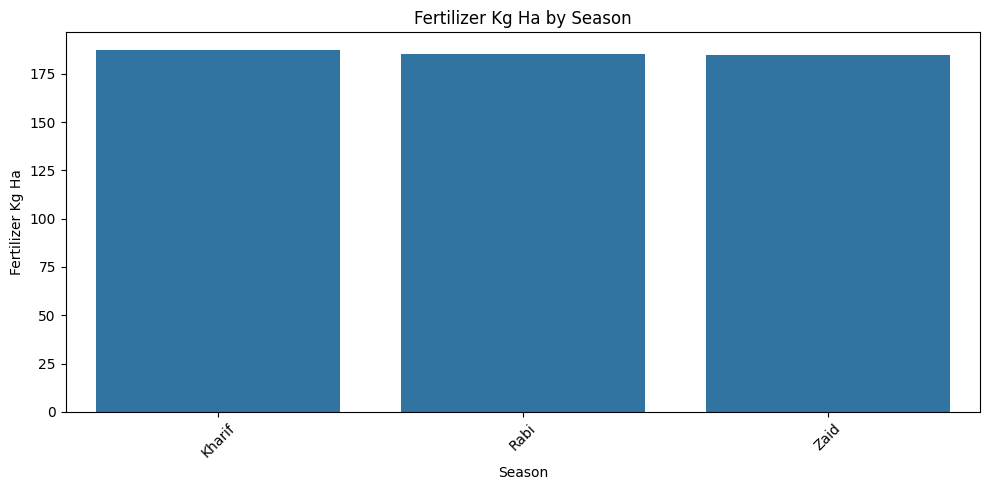

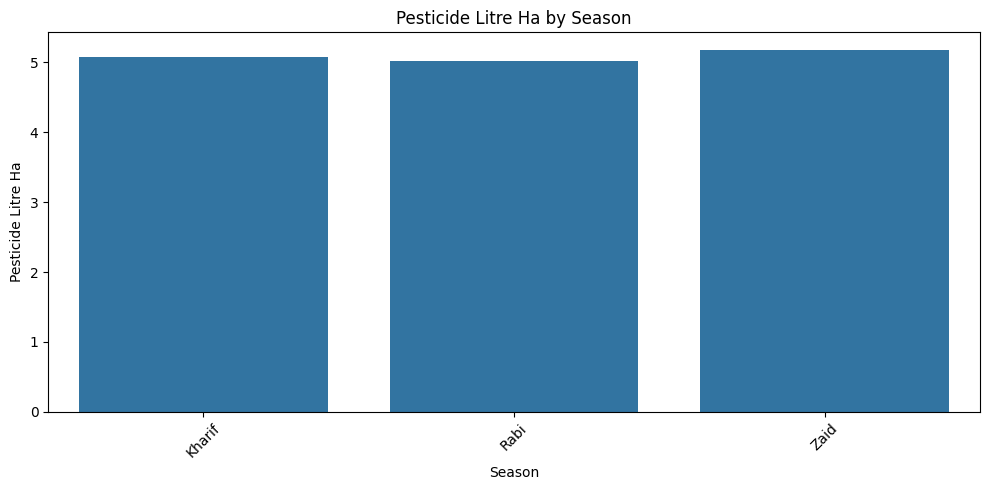

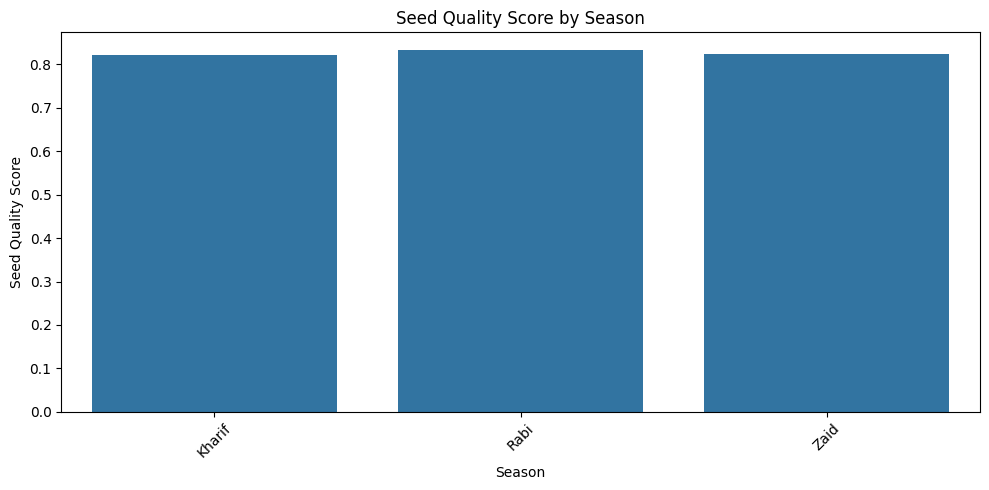

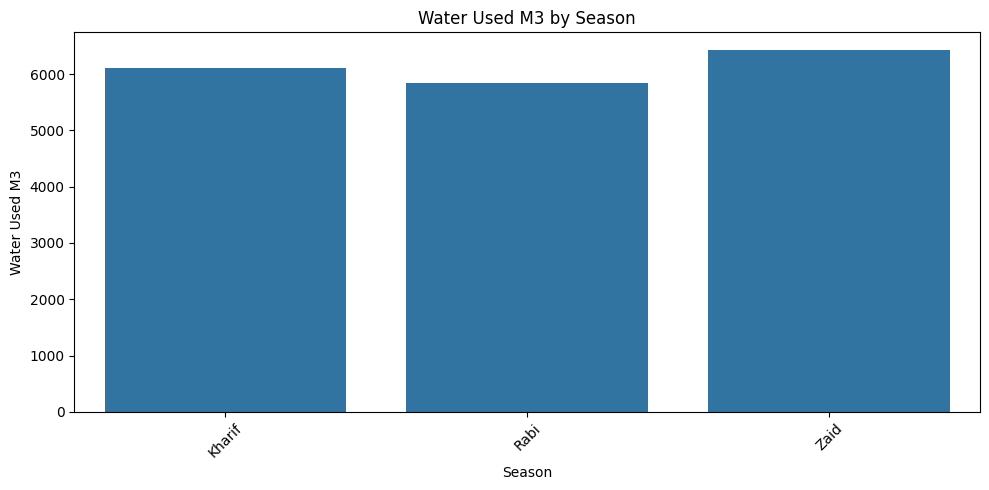

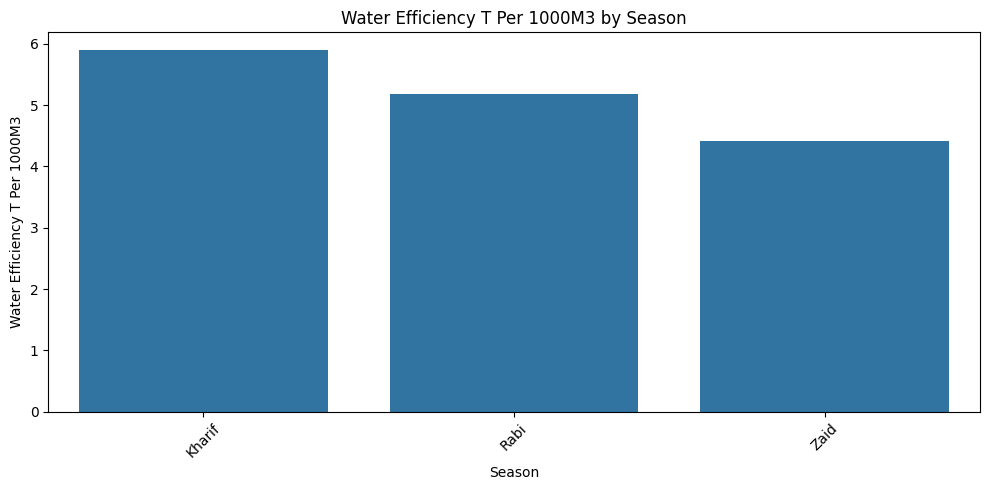

In [30]:
for column in resource_columns:

    if pd.api.types.is_numeric_dtype(df[column]):

        plt.figure(figsize=(10, 5))

        sns.barplot(
            data=df,
            x=season_col,
            y=column,
            estimator=np.mean,
            errorbar=None
        )

        plt.title(
            f"{column.replace('_', ' ').title()} by Season"
        )

        plt.xlabel("Season")
        plt.ylabel(column.replace("_", " ").title())

        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

In [31]:
economic_columns = [
    col for col in df.columns
    if any(word in col.lower()
           for word in [
               "income",
               "revenue",
               "profit",
               "cost",
               "price",
               "economic",
               "expense",
               "market"
           ])
]

print("Possible economic columns:")
print(economic_columns)

Possible economic columns:
['market_price_inr_tonne', 'total_cost_inr', 'revenue_inr', 'profit_inr']


In [32]:
for column in economic_columns:

    if pd.api.types.is_numeric_dtype(df[column]):

        result = (
            df.groupby(season_col)[column]
            .mean()
            .sort_values(ascending=False)
        )

        print(f"\nAverage {column} by season:")
        display(result)


Average market_price_inr_tonne by season:


,market_price_inr_tonne
season,
Kharif,44850.906127
Rabi,44747.974800
Zaid,44212.033670



Average total_cost_inr by season:


,total_cost_inr
season,
Zaid,543976.728956
Kharif,531804.408094
Rabi,513836.578365



Average revenue_inr by season:


,revenue_inr
season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040



Average profit_inr by season:


,profit_inr
season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


In [33]:
possible_region_columns = [
    col for col in df.columns
    if any(word in col.lower()
           for word in [
               "region",
               "state",
               "district",
               "area",
               "location",
               "geography"
           ])
]

print(possible_region_columns)

['state', 'district', 'farm_area_hectares']


In [37]:
region_col = "state"

In [38]:
regional_seasonal_performance = pd.pivot_table(
    df,
    values=performance_col,
    index=region_col,
    columns=season_col,
    aggfunc="mean"
)

display(
    regional_seasonal_performance.round(2)
)

season,Kharif,Rabi,Zaid
state,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


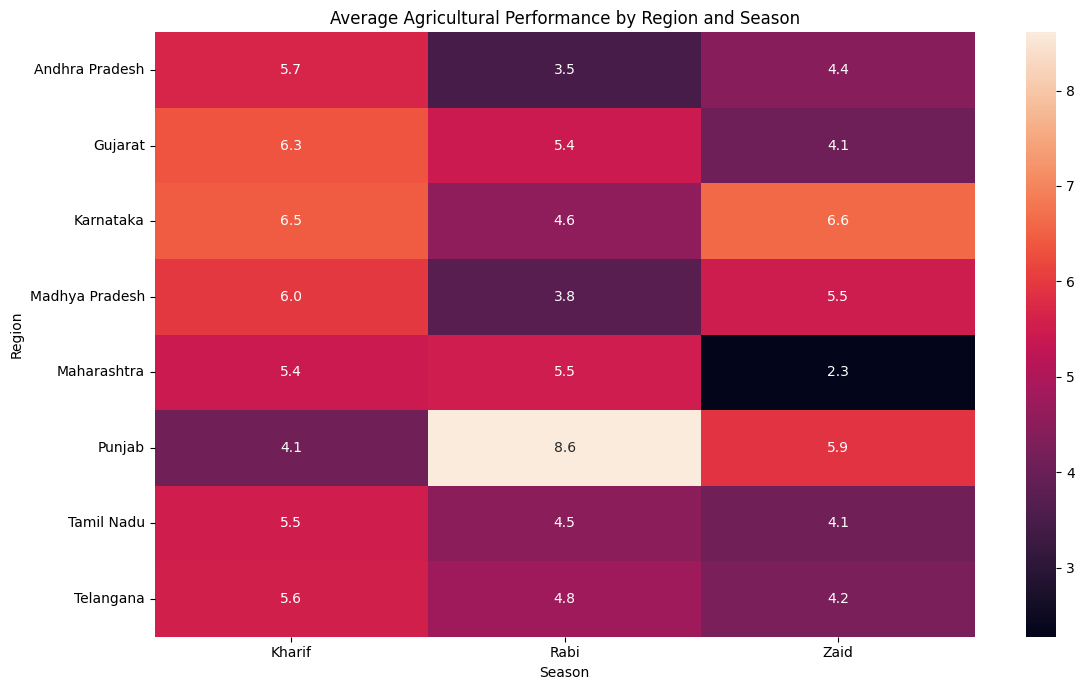

In [39]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    regional_seasonal_performance,
    annot=True,
    fmt=".1f"
)

plt.title(
    "Average Agricultural Performance by Region and Season"
)

plt.xlabel("Season")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [40]:
possible_crop_columns = [
    col for col in df.columns
    if any(word in col.lower()
           for word in [
               "crop",
               "category",
               "type",
               "variety"
           ])
]

print(possible_crop_columns)

['crop']


In [41]:
crop_col = "crop"

crop_season_analysis = pd.pivot_table(
    df,
    values=performance_col,
    index=crop_col,
    columns=season_col,
    aggfunc="mean"
)

display(crop_season_analysis.round(2))

season,Kharif,Rabi,Zaid
crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


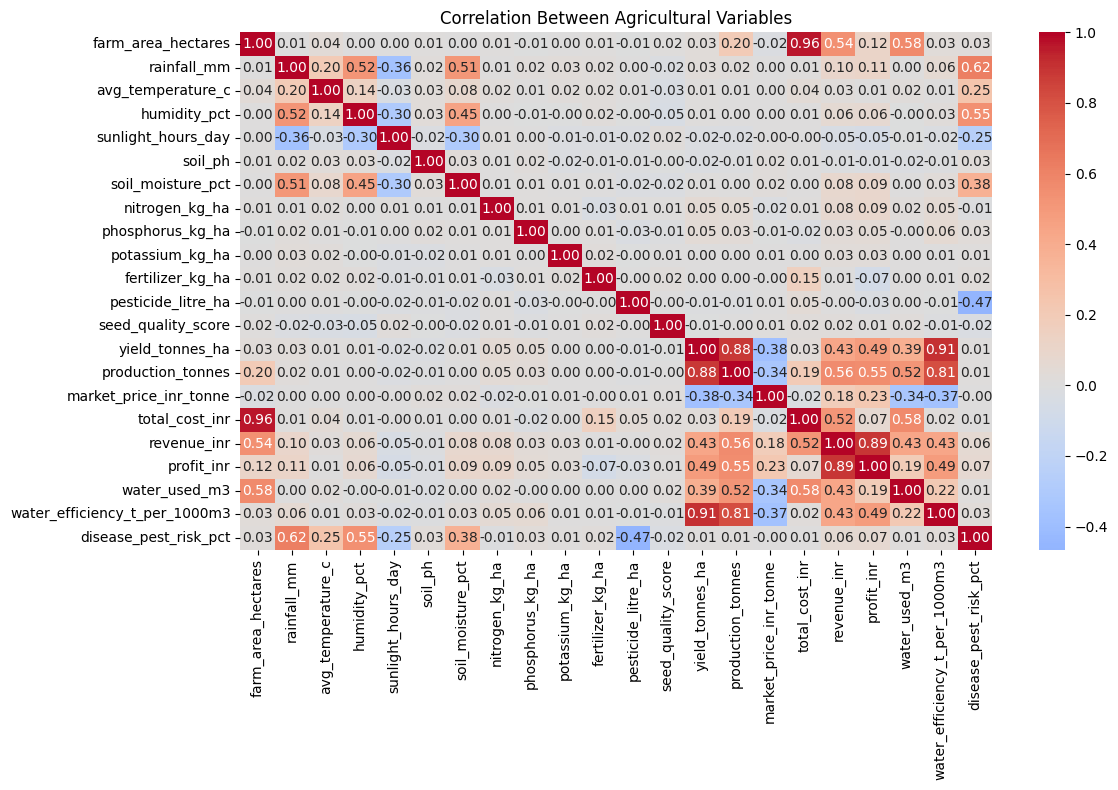

In [42]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Agricultural Variables")

plt.tight_layout()
plt.show()

In [43]:
performance_correlations = (
    correlation_matrix[performance_col]
    .sort_values(ascending=False)
)

print(
    "Variables most positively/negatively related "
    "to agricultural performance:"
)

display(performance_correlations)

Variables most positively/negatively related to agricultural performance:


,yield_tonnes_ha
yield_tonnes_ha,1.000000
water_efficiency_t_per_1000m3,0.912568
production_tonnes,0.882813
profit_inr,0.488466
revenue_inr,0.432152
water_used_m3,0.386294
nitrogen_kg_ha,0.053149
phosphorus_kg_ha,0.047941
rainfall_mm,0.030951
total_cost_inr,0.030622


In [46]:
if "rainfall" in df.columns:

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=df,
        x="rainfall",
        y=performance_col,
        hue=season_col
    )

    plt.title(
        "Relationship Between Rainfall and Agricultural Performance"
    )

    plt.xlabel("Rainfall")
    plt.ylabel("Agricultural Performance")

    plt.tight_layout()
    plt.show()

In [47]:
Q1 = df[performance_col].quantile(0.25)
Q3 = df[performance_col].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df[performance_col] < lower_limit) |
    (df[performance_col] > upper_limit)
]

print("Number of unusual performance records:", len(outliers))

display(outliers.head(20))

Number of unusual performance records: 302


,farm_id,state,district,crop,season,farm_area_hectares,rainfall_mm,avg_temperature_c,humidity_pct,sunlight_hours_day,soil_ph,soil_moisture_pct,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,irrigation_method,fertilizer_kg_ha,pesticide_litre_ha,seed_quality_score,yield_tonnes_ha,production_tonnes,market_price_inr_tonne,total_cost_inr,revenue_inr,profit_inr,water_used_m3,water_efficiency_t_per_1000m3,disease_pest_risk_pct
47,SF10048,Punjab,Ludhiana,Sugarcane,Zaid,7.68,90.0,31.9,52.7,9.8,6.51,18.3,164.0,59.6,54.9,Sprinkler,136.9,8.04,0.76,36.69,281.78,3682,480826,1037514,556688,13263,21.246,30.0
75,SF10076,Maharashtra,Guntur,Sugarcane,Kharif,10.64,869.0,33.2,82.3,5.6,6.42,37.4,148.0,104.4,90.2,Flood,212.2,5.80,0.79,62.58,665.85,3651,755288,2431018,1675730,23608,28.204,58.8
79,SF10080,Karnataka,Nashik,Sugarcane,Zaid,9.29,353.9,30.6,46.8,9.1,7.31,8.4,126.5,100.8,101.3,Rainfed,167.2,3.45,0.90,33.55,311.68,3955,541528,1232694,691166,8213,37.950,31.2
82,SF10083,Andhra Pradesh,Raichur,Sugarcane,Rabi,2.46,629.3,23.5,47.5,8.9,6.32,27.2,158.9,44.2,116.8,Rainfed,139.4,6.41,0.83,49.52,121.82,3654,165909,445130,279221,2611,46.656,35.2
92,SF10093,Gujarat,Guntur,Sugarcane,Kharif,12.74,973.7,29.9,57.5,7.4,6.65,25.8,110.1,57.6,89.8,Drip,134.0,4.39,0.72,70.23,894.73,3671,856862,3284554,2427692,18596,48.114,51.9
113,SF10114,Tamil Nadu,Rajkot,Sugarcane,Rabi,14.35,740.8,24.8,72.5,7.9,7.00,26.3,87.3,30.2,107.6,Sprinkler,147.1,2.23,0.92,58.06,833.16,3807,847509,3171840,2324331,27123,30.718,64.2
132,SF10133,Telangana,Warangal,Sugarcane,Kharif,3.83,1158.2,27.2,68.4,7.0,7.40,32.2,84.3,51.2,95.2,Sprinkler,252.4,5.08,0.82,29.47,112.87,3123,263380,352493,89113,6337,17.811,53.9
154,SF10155,Telangana,Ludhiana,Sugarcane,Kharif,9.12,932.6,29.3,65.5,8.7,6.38,34.0,40.0,69.1,113.1,Flood,229.1,4.19,0.82,47.88,436.67,3550,751898,1550178,798280,21550,20.263,54.4
155,SF10156,Madhya Pradesh,Guntur,Sugarcane,Kharif,4.50,867.9,27.3,66.6,7.2,6.17,38.2,115.9,48.2,91.2,Drip,225.6,4.01,0.82,62.09,279.41,3089,290078,863097,573019,8473,32.977,48.7
164,SF10165,Telangana,Guntur,Sugarcane,Rabi,4.00,391.2,25.6,59.8,8.7,7.19,21.8,76.7,74.6,111.1,Rainfed,189.6,7.85,0.67,36.91,147.64,3771,259517,556750,297233,3618,40.807,24.0


In [48]:
seasonal_outliers = (
    outliers[season_col]
    .value_counts()
)

print("Unusual observations by season:")
display(seasonal_outliers)

Unusual observations by season:


,count
season,
Kharif,129
Rabi,124
Zaid,49


In [49]:
seasons = df[season_col].dropna().unique()

print("Available seasons:")
print(seasons)

Available seasons:
['Kharif' 'Rabi' 'Zaid']


In [50]:
if len(seasons) == 2:

    group1 = df[
        df[season_col] == seasons[0]
    ][performance_col]

    group2 = df[
        df[season_col] == seasons[1]
    ][performance_col]

    t_stat, p_value = stats.ttest_ind(
        group1,
        group2,
        equal_var=False
    )

    print("T-statistic:", round(t_stat, 4))
    print("P-value:", round(p_value, 4))

    if p_value < 0.05:
        print(
            "The difference between the two seasons "
            "is statistically significant."
        )
    else:
        print(
            "No statistically significant difference "
            "was found between the two seasons."
        )

In [51]:
groups = [
    group[performance_col].dropna()
    for _, group in df.groupby(season_col)
]

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", round(f_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print(
        "Agricultural performance differs significantly "
        "across at least some seasons."
    )
else:
    print(
        "No statistically significant seasonal difference "
        "was detected."
    )

F-statistic: 1.5439
P-value: 0.2137
No statistically significant seasonal difference was detected.


In [52]:
season_summary = (
    df.groupby(season_col)[performance_col]
    .mean()
    .sort_values(ascending=False)
)

best_season = season_summary.index[0]
lowest_season = season_summary.index[-1]

print("Highest average performance:", best_season)
print("Lowest average performance:", lowest_season)

display(season_summary)

Highest average performance: Kharif
Lowest average performance: Zaid


,yield_tonnes_ha
season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


In [53]:
final_season_summary = (
    df.groupby(season_col)
    .agg(
        Average_Performance=(performance_col, "mean"),
        Median_Performance=(performance_col, "median"),
        Minimum_Performance=(performance_col, "min"),
        Maximum_Performance=(performance_col, "max"),
        Records=(performance_col, "count")
    )
    .round(2)
)

display(final_season_summary)

,Average_Performance,Median_Performance,Minimum_Performance,Maximum_Performance,Records
season,,,,,
Kharif,5.63,1.94,0.3,101.44,1779
Rabi,5.04,1.67,0.3,93.13,1627
Zaid,4.64,1.46,0.3,64.76,594


In [54]:
print("KEY FINDINGS")
print("=" * 60)

print(
    f"1. The season with the highest average "
    f"agricultural performance is {best_season}."
)

print(
    f"2. The season with the lowest average "
    f"agricultural performance is {lowest_season}."
)

print(
    f"3. The dataset contains {len(outliers)} "
    f"unusual performance observations."
)

print(
    f"4. The analysis considered {len(numeric_columns)} "
    f"numerical variables."
)

print(
    f"5. The dataset contains {len(df)} records "
    f"after cleaning."
)

KEY FINDINGS
1. The season with the highest average agricultural performance is Kharif.
2. The season with the lowest average agricultural performance is Zaid.
3. The dataset contains 302 unusual performance observations.
4. The analysis considered 22 numerical variables.
5. The dataset contains 4000 records after cleaning.
